In [1]:
import networkx as nx
from datasets import load_dataset
import matplotlib.pyplot as plt
import boto3

In [2]:
from dialogue_manager import DialogueManager
from graph_manager import GraphManager, fetch_answer_from_graph
from feedback_handler import FeedbackHandler

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Fetched Answer: Saint Bernadette Soubirous
Nodes: [('To', {}), ('whom', {}), ('did', {}), ('the', {}), ('Virgin', {}), ('Mary', {}), ('allegedly', {}), ('appear', {}), ('in', {}), ('1858', {}), ('Lourdes', {}), ('France?', {}), ('Saint', {}), ('Bernadette', {}), ('Soubirous', {}), ('What', {}), ('is', {}), ('front', {}), ('of', {}), ('Notre', {}), ('Dame', {}), ('Main', {}), ('Building?', {}), ('a', {}), ('copper', {}), ('statue', {}), ('Christ', {}), ('The', {}), ('Basilica', {}), ('Sacred', {}), ('heart', {}), ('at', {}), ('beside', {}), ('to', {}), ('which', {}), ('structure?', {}), ('Building', {}), ('Grotto', {}), ('Dame?', {}), ('Marian', {}), ('place', {}), ('prayer', {}), ('and', {}), ('reflection', {}), ('sits', {}), ('on', {}), ('top', {}), ('golden', {}), ('When', {}), ('Scholastic', {}), ('Magazine', {}), ('dame', {}), ('begin', {}), ('publishing?', {}), ('September', {}), ('1876', {}), ('How'

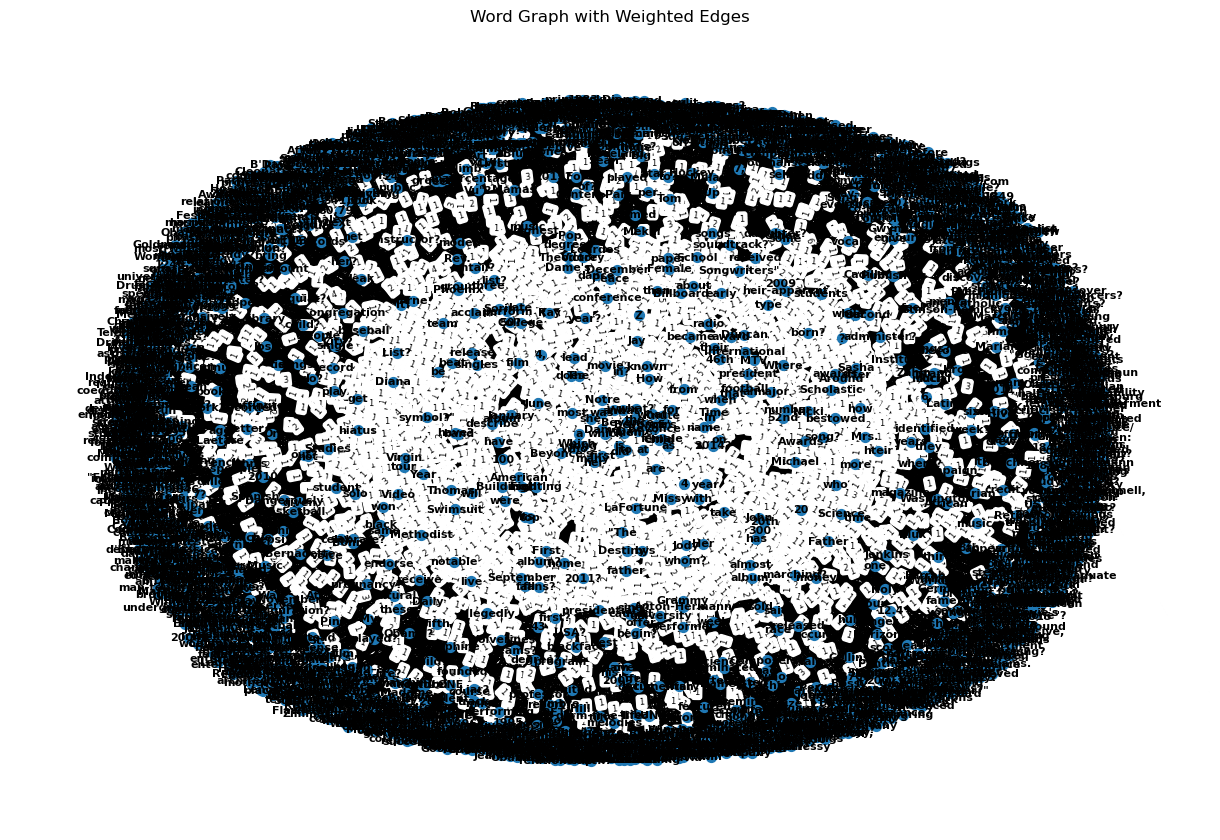

In [3]:
# Load the SQuAD dataset
dataset = load_dataset('squad', split='train[:1%]')  # Use a small subset for demonstration

# Initialize managers
dialogue_manager = DialogueManager()
graph_manager = GraphManager()
feedback_handler = FeedbackHandler(dialogue_manager, graph_manager)

# Process the dataset to build the graph
for example in dataset:
    question = example['question']
    answer = example['answers']['text'][0]  # Take the first answer for simplicity
    graph_manager.add_to_graph(question, answer)

# Fetch the answer for a given question
sample_question = dataset[0]['question']
fetched_answer = graph_manager.generate_answer(sample_question)

# Print the question and the fetched answer
print(f"Question: {sample_question}")
print(f"Fetched Answer: {fetched_answer}")

# Print the graph nodes and edges
print("Nodes:", graph_manager.G.nodes(data=True))
print("Edges:", graph_manager.G.edges(data=True))

# Visualize the graph (Optional)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph_manager.G, k=0.5)
nx.draw(graph_manager.G, pos, with_labels=True, node_size=50, font_size=8, font_color='black', font_weight='bold')
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in graph_manager.G.edges(data=True)}
nx.draw_networkx_edge_labels(graph_manager.G, pos, edge_labels=edge_labels, font_size=6)
plt.title('Word Graph with Weighted Edges')
plt.show()